In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq


#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


llm=ChatGroq(model="openai/gpt-oss-120b")

In [3]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [4]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [5]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [ ]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()  ### checkpointing memory

workflow = graph.compile(checkpointer=checkpointer)

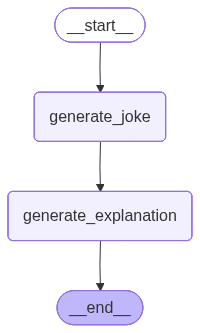

In [7]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [8]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'laptop'}, config=config1)

{'topic': 'laptop',
 'joke': "Why did the laptop go to therapy?  \n\nBecause it couldn't stop *scrolling* through its feelings and kept *crashing* every time someone tried to open up! 😄",
 'explanation': "**Explanation of the Joke**\n\n| Part of the Joke | What It Means Literally (Computer‑World) | What It Means Figuratively (Human‑World) |\n|------------------|-------------------------------------------|-------------------------------------------|\n| **“Why did the laptop go to therapy?”** | Sets up a classic “why‑did‑the‑…‑cross the road” style question, but the subject is a piece of technology instead of a person. | Implies the laptop has emotional or psychological problems that need professional help—just like a person would. |\n| **“Because it couldn't stop *scrolling* through its feelings”** | *Scrolling* is the action of moving a cursor or finger up and down a screen to view more content. | *Scrolling through its feelings* plays on the phrase “going through one’s feelings.” It s

In [9]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'laptop', 'joke': "Why did the laptop go to therapy?  \n\nBecause it couldn't stop *scrolling* through its feelings and kept *crashing* every time someone tried to open up! 😄", 'explanation': "**Explanation of the Joke**\n\n| Part of the Joke | What It Means Literally (Computer‑World) | What It Means Figuratively (Human‑World) |\n|------------------|-------------------------------------------|-------------------------------------------|\n| **“Why did the laptop go to therapy?”** | Sets up a classic “why‑did‑the‑…‑cross the road” style question, but the subject is a piece of technology instead of a person. | Implies the laptop has emotional or psychological problems that need professional help—just like a person would. |\n| **“Because it couldn't stop *scrolling* through its feelings”** | *Scrolling* is the action of moving a cursor or finger up and down a screen to view more content. | *Scrolling through its feelings* plays on the phrase “going through on

In [10]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'laptop', 'joke': "Why did the laptop go to therapy?  \n\nBecause it couldn't stop *scrolling* through its feelings and kept *crashing* every time someone tried to open up! 😄", 'explanation': "**Explanation of the Joke**\n\n| Part of the Joke | What It Means Literally (Computer‑World) | What It Means Figuratively (Human‑World) |\n|------------------|-------------------------------------------|-------------------------------------------|\n| **“Why did the laptop go to therapy?”** | Sets up a classic “why‑did‑the‑…‑cross the road” style question, but the subject is a piece of technology instead of a person. | Implies the laptop has emotional or psychological problems that need professional help—just like a person would. |\n| **“Because it couldn't stop *scrolling* through its feelings”** | *Scrolling* is the action of moving a cursor or finger up and down a screen to view more content. | *Scrolling through its feelings* plays on the phrase “going through o

In [11]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti go to therapy?  \n\nBecause it couldn’t stop *pasta*-tively worrying about getting tangled up in its own thoughts! 🍝😆',
 'explanation': '**Explanation of the joke**\n\n> *Why did the spaghetti go to therapy? Because it couldn’t stop **pasta‑tively** worrying about getting tangled up in its own thoughts! 🍝😆*\n\n---\n\n### 1. The setup: “Why did the spaghetti go to therapy?”\n- **Therapy** is a place people (or, in jokes, anthropomorphized objects) go when they’re feeling anxious, stressed, or overwhelmed.\n- By asking why a *food*—spaghetti—needs therapy, the joke immediately sets up an absurd, whimsical scenario. The humor starts with the image of a noodle sitting on a therapist’s couch, which is inherently funny because noodles obviously don’t have feelings.\n\n### 2. The punchline: “Because it couldn’t stop *pasta‑tively* worrying about getting tangled up in its own thoughts!”\n- **Wordplay on “pasta‑tively”**  \n  - The joke swaps t

In [14]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti go to therapy?  \n\nBecause it couldn’t stop *pasta*-tively worrying about getting tangled up in its own thoughts! 🍝😆', 'explanation': '**Explanation of the joke**\n\n> *Why did the spaghetti go to therapy? Because it couldn’t stop **pasta‑tively** worrying about getting tangled up in its own thoughts! 🍝😆*\n\n---\n\n### 1. The setup: “Why did the spaghetti go to therapy?”\n- **Therapy** is a place people (or, in jokes, anthropomorphized objects) go when they’re feeling anxious, stressed, or overwhelmed.\n- By asking why a *food*—spaghetti—needs therapy, the joke immediately sets up an absurd, whimsical scenario. The humor starts with the image of a noodle sitting on a therapist’s couch, which is inherently funny because noodles obviously don’t have feelings.\n\n### 2. The punchline: “Because it couldn’t stop *pasta‑tively* worrying about getting tangled up in its own thoughts!”\n- **Wordplay on “pasta‑tively”**  \n 

In [13]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'laptop', 'joke': "Why did the laptop go to therapy?  \n\nBecause it couldn't stop *scrolling* through its feelings and kept *crashing* every time someone tried to open up! 😄", 'explanation': "**Explanation of the Joke**\n\n| Part of the Joke | What It Means Literally (Computer‑World) | What It Means Figuratively (Human‑World) |\n|------------------|-------------------------------------------|-------------------------------------------|\n| **“Why did the laptop go to therapy?”** | Sets up a classic “why‑did‑the‑…‑cross the road” style question, but the subject is a piece of technology instead of a person. | Implies the laptop has emotional or psychological problems that need professional help—just like a person would. |\n| **“Because it couldn't stop *scrolling* through its feelings”** | *Scrolling* is the action of moving a cursor or finger up and down a screen to view more content. | *Scrolling through its feelings* plays on the phrase “going through o

In [15]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti go to therapy?  \n\nBecause it couldn’t stop *pasta*-tively worrying about getting tangled up in its own thoughts! 🍝😆', 'explanation': '**Explanation of the joke**\n\n> *Why did the spaghetti go to therapy? Because it couldn’t stop **pasta‑tively** worrying about getting tangled up in its own thoughts! 🍝😆*\n\n---\n\n### 1. The setup: “Why did the spaghetti go to therapy?”\n- **Therapy** is a place people (or, in jokes, anthropomorphized objects) go when they’re feeling anxious, stressed, or overwhelmed.\n- By asking why a *food*—spaghetti—needs therapy, the joke immediately sets up an absurd, whimsical scenario. The humor starts with the image of a noodle sitting on a therapist’s couch, which is inherently funny because noodles obviously don’t have feelings.\n\n### 2. The punchline: “Because it couldn’t stop *pasta‑tively* worrying about getting tangled up in its own thoughts!”\n- **Wordplay on “pasta‑tively”**  \n